In [1]:
# imports
import pilotpy as pl
import scanpy as sc

/home/charlottewolf/miniconda3/envs/PILOT/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/home/charlottewolf/miniconda3/envs/PILOT/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/charlottewolf/miniconda3/envs/PILOT/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/charlottewolf/miniconda3/envs/PILOT/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `a

In [2]:
adata = sc.read_h5ad('Datasets/PDAC.h5ad')

In [3]:
adata

AnnData object with n_obs × n_vars = 57530 × 23376
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'peng_cluster', 'RNA_snn_res.0.8', 'seurat_clusters.res=1', 'r2', 'note', 'pathologic_diagnoses', 'Gender', 'CA199', 'Procedure', 'Maximum_Diameter_mm', 'Staging', 'vascular_invasion', 'Age', 'Diabetes', 'Location', 'TNM_Classification', 'perineural_invasion', 'peripancreatic_infiltarion', 'RNA_snn_res.1', 'RNA_snn_res.0.1', 'seurat_clusters.res=0.1', 'RNA_snn_res.0.2', 'seurat_clusters.res=0.2', 'RNA_snn_res.0.3', 'seurat_clusters.res=0.3', 'RNA_snn_res.0.4', 'seurat_clusters.res=0.4', 'RNA_snn_res.0.5', 'seurat_clusters.res=0.5', 'RNA_snn_res.0.6', 'seurat_clusters.res=0.6', 'RNA_snn_res.0.7', 'seurat_clusters.res=0.7', 'seurat_clusters.res=0.8', 'RNA_snn_res.0.9', 'seurat_clusters.res=0.9', 'Cluster_res0.9_anno', 'Cluster_res0.9_anno_combined', 'accAnnot', 'accSample', 'accLabel', 'accLabel1', 'sampleID', 'cell_types', 'status'
    var: 'vst.mean', 'vst.variance', 'v

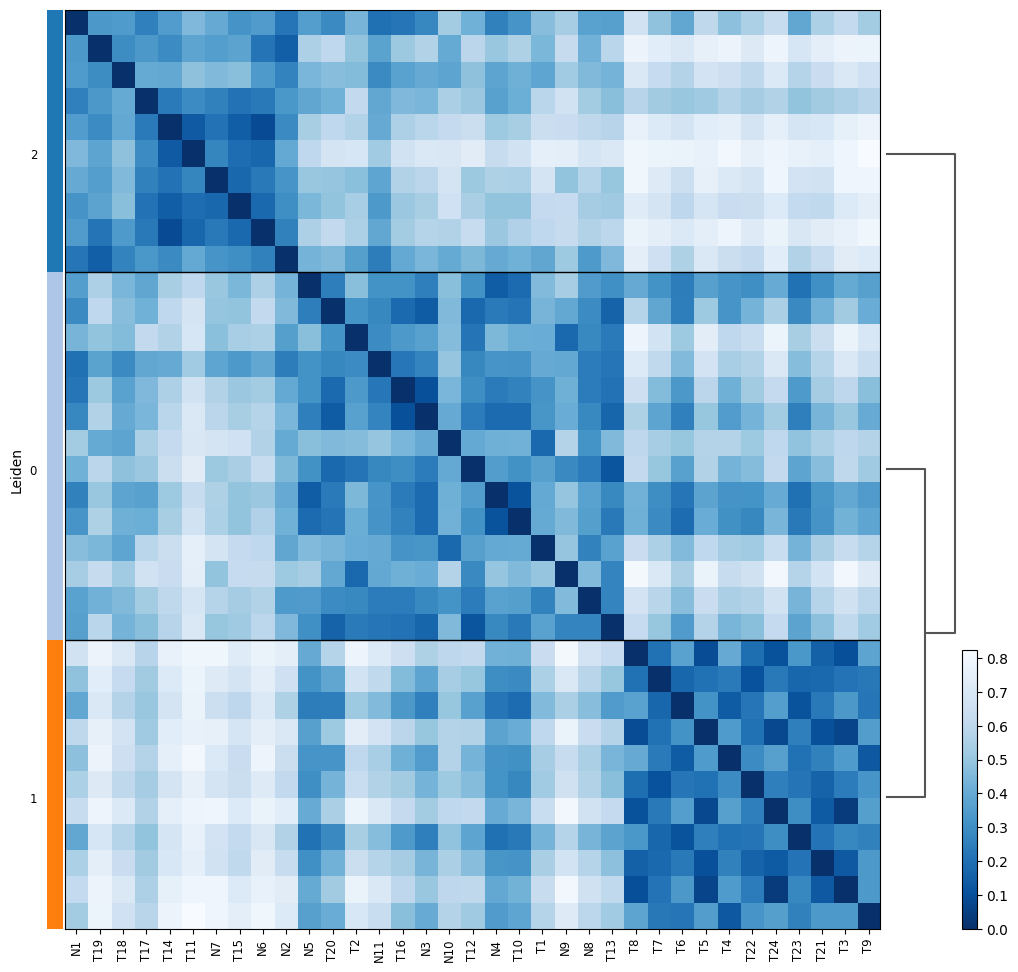

In [4]:
proportion_df=pl.pl.clustering_emd(adata, res = adata.uns['best_res'])

In [5]:
proportion_df.loc[proportion_df['Predicted_Labels'] == '0', 'Predicted_Labels'] = 'Tumor 1'
proportion_df.loc[proportion_df['Predicted_Labels'] == '1', 'Predicted_Labels'] = 'Normal'
proportion_df.loc[proportion_df['Predicted_Labels'] == '2', 'Predicted_Labels'] = 'Tumor 2'

In [6]:
proportion_df

,Fibroblast cell,Stellate cell,Macrophage cell,Endothelial cell,T cell,B cell,Ductal cell type 2,Endocrine cell,Ductal cell type 1,Acinar cell,Predicted_Labels,sampleID
N1,0.106625,0.046408,0.028343,0.187387,0.003192,0.000003,0.001076,0.007439,0.602166,0.017359,Tumor 2,N1
N10,0.003256,0.011029,0.012972,0.168502,0.000008,0.000006,0.000025,0.003241,0.643491,0.157470,Tumor 1,N10
N11,0.028233,0.010143,0.041976,0.565064,0.000009,0.000007,0.002922,0.001449,0.319083,0.031115,Tumor 1,N11
N2,0.086272,0.027572,0.054113,0.161817,0.003579,0.000005,0.000020,0.016334,0.384869,0.265418,Tumor 2,N2
N3,0.035202,0.162609,0.070341,0.248312,0.024191,0.000020,0.000086,0.057123,0.386722,0.015394,Tumor 1,N3
N4,0.026713,0.017470,0.000020,0.207382,0.000012,0.000009,0.001067,0.007188,0.740131,0.000008,Tumor 1,N4
N5,0.009044,0.029328,0.003403,0.227718,0.001141,0.000010,0.000044,0.007892,0.702250,0.019170,Tumor 1,N5
N6,0.111423,0.071038,0.009773,0.459526,0.005586,0.000013,0.001447,0.008357,0.325865,0.006972,Tumor 2,N6
N7,0.017955,0.040369,0.006294,0.184749,0.001804,0.000008,0.000932,0.059184,0.648346,0.040358,Tumor 2,N7
N8,0.117214,0.088526,0.082789,0.294240,0.006566,0.000827,0.000852,0.035242,0.308995,0.064750,Tumor 1,N8


In [7]:
cell_type = "Ductal cell type 1" #look at the Cells folder
pl.tl.compute_diff_expressions(
    adata,
    cell_type,
    proportion_df,
    fc_thr =  0.5,
    pval_thr = 0.05,
    group1 = 'Tumor 1', 
    group2 = 'Tumor 2',
    sample_col = 'sampleID',
    col_cell = 'cell_types',
    )

KeyError: 'sampIeD'

In [ ]:
def run_with_pydeseq2():
    